## K-Nearest Neighbors (KNN)

- The k-nearest neighbors (KNN) algorithm is a non-parametric, supervised learning classifier, which uses proximity to make classifications or predictions about the grouping of an individual data point.
- This model assumes that similar point can be found near each other.

In [1]:
import numpy as np
import pandas as pd

x = np.array([
    [1, 1],
    [1, 2],
    [2, 1],
    [8, 8],
    [8, 9],
    [9, 8]
])

y = np.array([0, 0, 0, 1, 1, 1])

df = pd.DataFrame(x, columns=["x1", "x2"])
df["label"] = y
df

,x1,x2,label
0,1,1,0
1,1,2,0
2,2,1,0
3,8,8,1
4,8,9,1
5,9,8,1


### Why distance makes sense here ?

- We assume that similar points can be found together. So we need distance between points to identify which points are together and which are far. 

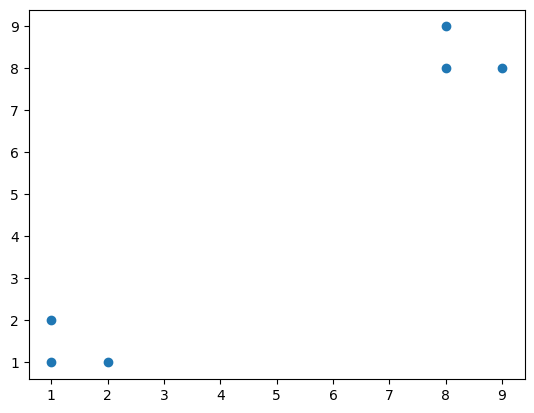

In [2]:
import matplotlib.pyplot as plt

plot = plt.scatter(x[:, 0], x[:, 1])

### What does “training” mean for KNN ?

- In the context of the K-Nearest Neighbors (KNN) algorithm, "training" does not involve learning a model or fitting parameters from the data. Instead, the training phase consists solely of storing the entire dataset.

In [3]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)
model.fit(x, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [4]:
test_point = np.array([[2,2]])
model.predict(test_point)

array([0])

### Which neighbors influenced the decision ?

- Our test point is [2,2] so its neighbors which influenced are it's nearest such as [1,1], [2,1] and [1,2]. Only this three because we have set k = 3 in form of n_neighbor = 3.

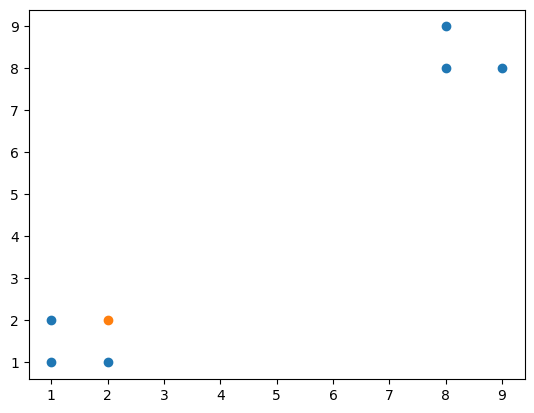

In [5]:
plot = plt.scatter(x[:, 0], x[:, 1])
plt.scatter(test_point[0,0], test_point[0,1])

### How increasing k changes behavior ?

- In KNN 'k' represents number of neighbor model will consider during decision making and we can set it by using n_neighbor parameter as done in cell 9. Thus, by increasing 'k' model considers more neighbor and then consider majority among those neighbor which ever class has higher majority is the class given to the instant.

### Scaling Effect

### What happens if one feature has larger scale ? 

- If one feature has larger scale it will heavily influence model's prediction due to KNN's heavy reliance on distance metric and feature with higher scaling will overshadow feature with smaller scaling. As we can see this brakes model's prediction and we can solve it by using StandardScaler. And that is why StandardScaler are important you can learn more about scaling in "02_statistics_for_ml" notebook. 